Распознавание рукописного ввода на примере базы MNIST

Построить классификатор изображений рукописного ввода на базе MNIST. В качестве шаблона в данной работе можно использовать ipython-ноутбук 002-digit.ipynb. https://github.com/a4tunado/lectures/blob/master/002/002-digit.ipynb

Классификатор предлагается строить на признаках, полученных в результате предобработки изображений, например, гистограммы градиентов (HOG) или результат PCA преобразования.

В качестве модели классификатора можно использовать любую известную Вам модель, за исключением сверточных нейронных сетей.

Критерием качества классификатора является метрика accuracy. Для получения зачета по данной работе, значение метрики accuracy должно быть больше 0.6. Метрика оценивается на тестовой выборке в рамках контеста Digit Recognizer на Kaggle. https://www.kaggle.com/c/digit-recognizer

Решение необходимо предоставить в виде ipython-ноутбука с реализацией процесса построения модели и скриншота с финальным результатом на Kaggle.

In [3]:
%matplotlib inline
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier, Perceptron, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA

In [4]:
train = np.loadtxt('/home/slava/Documents/netology_ML/CV/digit-recognizer/train.csv', delimiter=',', skiprows=1)
test = np.loadtxt('/home/slava/Documents/netology_ML/CV/digit-recognizer/test.csv', delimiter=',', skiprows=1)

# сохраняем разметку в отдельную переменную
train_label = train[:, 0]
test_label = test[:, 0]
# приводим размерность к удобному для обаботки виду
train_img = np.resize(train[:, 1:], (train.shape[0], 28, 28))

unique_train = np.unique(train_label)
unique_test = np.unique(test_label)
print(f"Unique classes in train: {unique_train}")
print(f"Unique classes in test: {unique_test}")

Unique classes in train: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
Unique classes in test: [0.]


## В тесте данные для соревнований видимо, там нет лейблов и оценить модель не получится придется делить train


In [5]:
train.shape

(42000, 785)

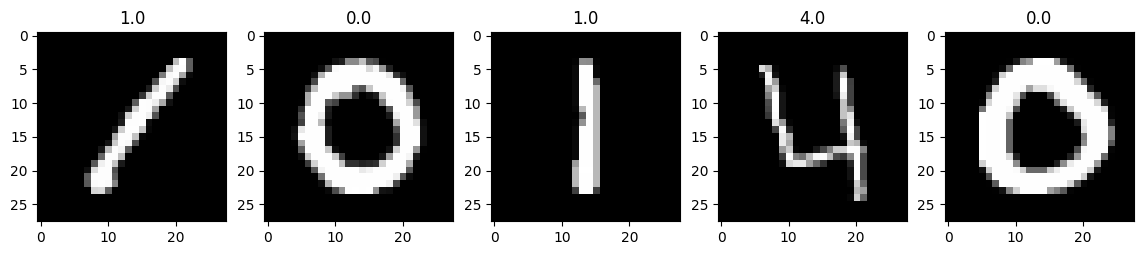

In [6]:
fig = plt.figure(figsize=(20, 10))
for i, img in enumerate(train_img[0:5], 1):
    subplot = fig.add_subplot(1, 7, i)
    plt.imshow(img, cmap='gray');
    subplot.set_title('%s' % train_label[i - 1]);

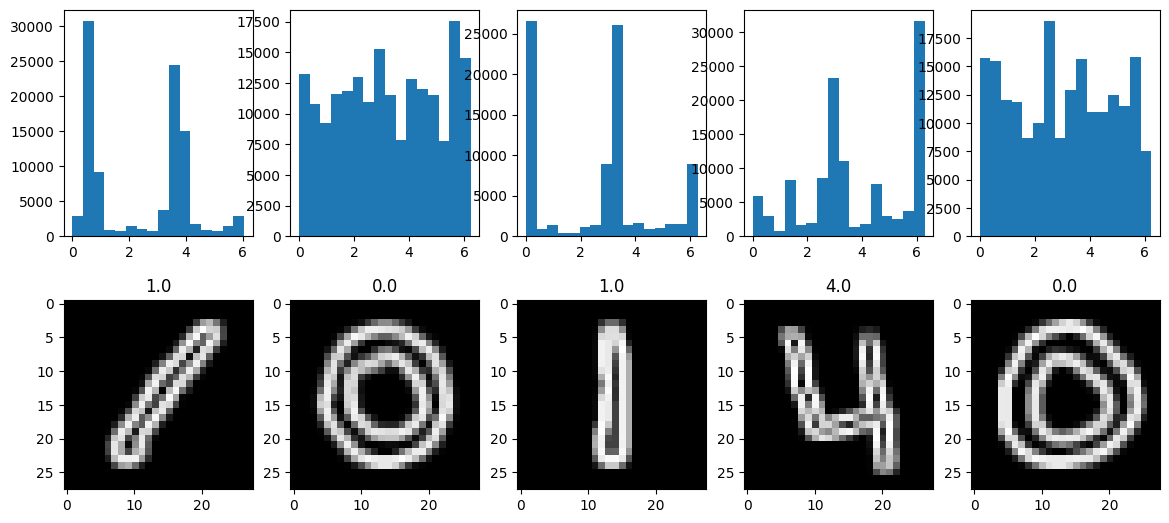

In [7]:
train_sobel_x = np.zeros_like(train_img)
train_sobel_y = np.zeros_like(train_img)
for i in range(len(train_img)):
    train_sobel_x[i] = cv2.Sobel(train_img[i], cv2.CV_64F, dx=1, dy=0, ksize=3)
    train_sobel_y[i] = cv2.Sobel(train_img[i], cv2.CV_64F, dx=0, dy=1, ksize=3)

train_g, train_theta = cv2.cartToPolar(train_sobel_x, train_sobel_y)

fig = plt.figure(figsize=(20, 10))
for i, img in enumerate(train_g[:5], 1):
    subplot = fig.add_subplot(1, 7, i)
    plt.imshow(img, cmap='gray');
    subplot.set_title('%s' % train_label[i - 1]);
    subplot = fig.add_subplot(3, 7, i)
    plt.hist(train_theta[i - 1].flatten(),
             bins=16, weights=train_g[i - 1].flatten())

In [8]:
# Гистограммы вычисляются с учетом длины вектора градиента
train_hist = np.zeros((len(train_img), 16))
for i in range(len(train_img)):
    hist, borders = np.histogram(train_theta[i],
                                 bins=16,
                                 range=(0., 2. * np.pi),
                                 weights=train_g[i])
    train_hist[i] = hist

# По умолчанию используется L2 норма
train_hist = train_hist / np.linalg.norm(train_hist, axis=1)[:, None]

In [9]:
train_df = pd.DataFrame(
    train_hist,
    columns=[f'hist_bin_{i}' for i in range(train_hist.shape[1])]
)

train_df.head()

,hist_bin_0,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10,hist_bin_11,hist_bin_12,hist_bin_13,hist_bin_14,hist_bin_15
0,0.089653,0.685882,0.129910,0.018789,0.036286,0.010821,0.021451,0.049259,0.114048,0.688540,0.090521,0.037883,0.016387,0.021923,0.026076,0.042718
1,0.268965,0.231884,0.173781,0.235131,0.239904,0.293877,0.191548,0.307797,0.263773,0.187534,0.235654,0.209687,0.286184,0.109791,0.379614,0.265978
2,0.673573,0.022191,0.033547,0.011270,0.011237,0.028629,0.036029,0.224570,0.659046,0.036195,0.038084,0.021414,0.025650,0.038116,0.036920,0.225488
3,0.135315,0.073868,0.010249,0.188463,0.037353,0.044008,0.193317,0.524754,0.251105,0.034832,0.035959,0.174654,0.068277,0.058779,0.082216,0.716659
4,0.306013,0.315100,0.218902,0.229895,0.169465,0.202886,0.361989,0.169293,0.291792,0.318122,0.173805,0.197307,0.273752,0.247597,0.252635,0.145500


In [10]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_hist)

X_train, X_val, y_train, y_val = train_test_split(
    train_scaled, train_label, 
    test_size=0.2, 
    random_state=42,
    stratify=train_label
)

dt = DecisionTreeClassifier(random_state=11)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.27      0.28      0.28       827
         1.0       0.93      0.92      0.93       937
         2.0       0.31      0.32      0.31       835
         3.0       0.49      0.47      0.48       870
         4.0       0.54      0.51      0.52       814
         5.0       0.50      0.48      0.49       759
         6.0       0.31      0.33      0.32       827
         7.0       0.68      0.70      0.69       880
         8.0       0.34      0.36      0.35       813
         9.0       0.46      0.44      0.45       838

    accuracy                           0.49      8400
   macro avg       0.48      0.48      0.48      8400
weighted avg       0.49      0.49      0.49      8400



## Ну такое себе. Для зачета нужно ещё 12%. Но кажется, что для начала лучше выбрать самую подходящую модель.

In [13]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.40      0.33      0.36       827
         1.0       0.92      0.95      0.94       937
         2.0       0.43      0.32      0.37       835
         3.0       0.58      0.66      0.61       870
         4.0       0.61      0.60      0.60       814
         5.0       0.56      0.62      0.59       759
         6.0       0.42      0.41      0.41       827
         7.0       0.77      0.79      0.78       880
         8.0       0.45      0.54      0.49       813
         9.0       0.55      0.53      0.54       838

    accuracy                           0.58      8400
   macro avg       0.57      0.57      0.57      8400
weighted avg       0.57      0.58      0.58      8400



## Уф.. самая простая, а уже такой результат! Осталось 3%, но сначала посмотрим, что могут остальные.

In [16]:
sgd = SGDClassifier(max_iter=1000, tol=1e-3)
sgd.fit(X_train, y_train)
y_pred = sgd.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.28      0.27      0.28       827
         1.0       0.88      0.96      0.92       937
         2.0       0.19      0.17      0.18       835
         3.0       0.54      0.64      0.59       870
         4.0       0.39      0.40      0.39       814
         5.0       0.50      0.68      0.58       759
         6.0       0.33      0.36      0.35       827
         7.0       0.65      0.77      0.71       880
         8.0       0.52      0.31      0.39       813
         9.0       0.52      0.33      0.40       838

    accuracy                           0.50      8400
   macro avg       0.48      0.49      0.48      8400
weighted avg       0.49      0.50      0.48      8400



In [18]:
perceptron = Perceptron(max_iter=1000)
perceptron.fit(X_train, y_train)
y_pred = perceptron.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.30      0.31      0.31       827
         1.0       0.89      0.85      0.87       937
         2.0       0.32      0.09      0.14       835
         3.0       0.34      0.86      0.48       870
         4.0       0.34      0.15      0.21       814
         5.0       0.60      0.41      0.49       759
         6.0       0.24      0.31      0.27       827
         7.0       0.45      0.55      0.49       880
         8.0       0.52      0.16      0.25       813
         9.0       0.37      0.41      0.39       838

    accuracy                           0.42      8400
   macro avg       0.44      0.41      0.39      8400
weighted avg       0.44      0.42      0.40      8400



In [20]:
passAggresive = PassiveAggressiveClassifier(max_iter=1000)
passAggresive.fit(X_train, y_train)
y_pred = passAggresive.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.19      0.03      0.04       827
         1.0       0.89      0.63      0.74       937
         2.0       0.22      0.46      0.30       835
         3.0       0.19      0.05      0.08       870
         4.0       0.36      0.33      0.35       814
         5.0       0.55      0.44      0.49       759
         6.0       0.25      0.59      0.35       827
         7.0       0.33      0.31      0.32       880
         8.0       0.46      0.35      0.40       813
         9.0       0.39      0.43      0.41       838

    accuracy                           0.36      8400
   macro avg       0.38      0.36      0.35      8400
weighted avg       0.39      0.36      0.35      8400



/home/slava/edu_env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


## Ничего хорошего не получилось. Ок, а ансамблирование?

In [23]:
randomForest = RandomForestClassifier(random_state=12)
randomForest.fit(X_train, y_train)
y_pred = randomForest.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.45      0.44      0.44       827
         1.0       0.98      0.94      0.96       937
         2.0       0.51      0.47      0.49       835
         3.0       0.63      0.69      0.66       870
         4.0       0.66      0.68      0.67       814
         5.0       0.69      0.66      0.67       759
         6.0       0.48      0.44      0.46       827
         7.0       0.83      0.80      0.81       880
         8.0       0.52      0.57      0.54       813
         9.0       0.65      0.68      0.67       838

    accuracy                           0.64      8400
   macro avg       0.64      0.64      0.64      8400
weighted avg       0.64      0.64      0.64      8400



In [25]:
bagging = BaggingClassifier(DecisionTreeClassifier(),
                           n_estimators=10,
                           max_samples=0.5,
                           max_features=0.5,
                           random_state=11)
bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.31      0.39      0.35       827
         1.0       0.94      0.94      0.94       937
         2.0       0.35      0.39      0.37       835
         3.0       0.53      0.57      0.55       870
         4.0       0.56      0.62      0.59       814
         5.0       0.56      0.54      0.55       759
         6.0       0.39      0.35      0.37       827
         7.0       0.78      0.73      0.75       880
         8.0       0.43      0.37      0.40       813
         9.0       0.59      0.48      0.53       838

    accuracy                           0.54      8400
   macro avg       0.54      0.54      0.54      8400
weighted avg       0.55      0.54      0.55      8400



## RandomForest с ходу решил на требуемое в ДЗ значение! А если объединить?

In [29]:
stacking = StackingClassifier(
    [
        ('BaggingClassifier', BaggingClassifier(DecisionTreeClassifier(),
                           n_estimators=10,
                           max_samples=0.5,
                           max_features=0.5,
                           random_state=11)),
        ('RandomForestClassifier', RandomForestClassifier(random_state=12))
    ], LogisticRegression(max_iter=1000))
stacking.fit(X_train, y_train)
y_pred = stacking.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.43      0.43      0.43       827
         1.0       0.99      0.94      0.96       937
         2.0       0.48      0.51      0.49       835
         3.0       0.64      0.64      0.64       870
         4.0       0.66      0.69      0.68       814
         5.0       0.69      0.65      0.67       759
         6.0       0.47      0.45      0.46       827
         7.0       0.83      0.80      0.82       880
         8.0       0.53      0.55      0.54       813
         9.0       0.64      0.68      0.66       838

    accuracy                           0.64      8400
   macro avg       0.64      0.63      0.63      8400
weighted avg       0.64      0.64      0.64      8400



In [30]:
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=12)),
    ('knn', KNeighborsClassifier(n_neighbors=3, weights='distance')),
    ('svm', make_pipeline(StandardScaler(), LinearSVC(C=1.0, max_iter=2000, random_state=12))),
    ('nb', GaussianNB())
]

stackingPro = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(C=1.0, max_iter=1000),
    cv=5
)

stackingPro.fit(X_train, y_train)
y_pred = stackingPro.predict(X_val)
print(classification_report(y_val, y_pred))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
              precision    recall  f1-score   support

         0.0       0.46      0.47      0.47       827
         1.0       0.98      0.95      0.96       937
         2.0       0.51      0.50      0.50       835
         3.0       0.66      0.68      0.67       870
         4.0       0.70      0.70      0.70       814
         5.0       0.67      0.63      0.65       759
         6.0       0.50      0.48      0.49       827
         7.0       0.86      0.83      0.84       880
         8.0       0.54      0.58      0.56       813
         9.0       0.65      0.70      0.67       838

    accuracy                           0.66      8400
   macro avg       0.65      0.65      0.65      8400
weighted avg       0.66      0.66      0.66      8400



## Чет не очень, а если добавить признаков из РСА анализа?

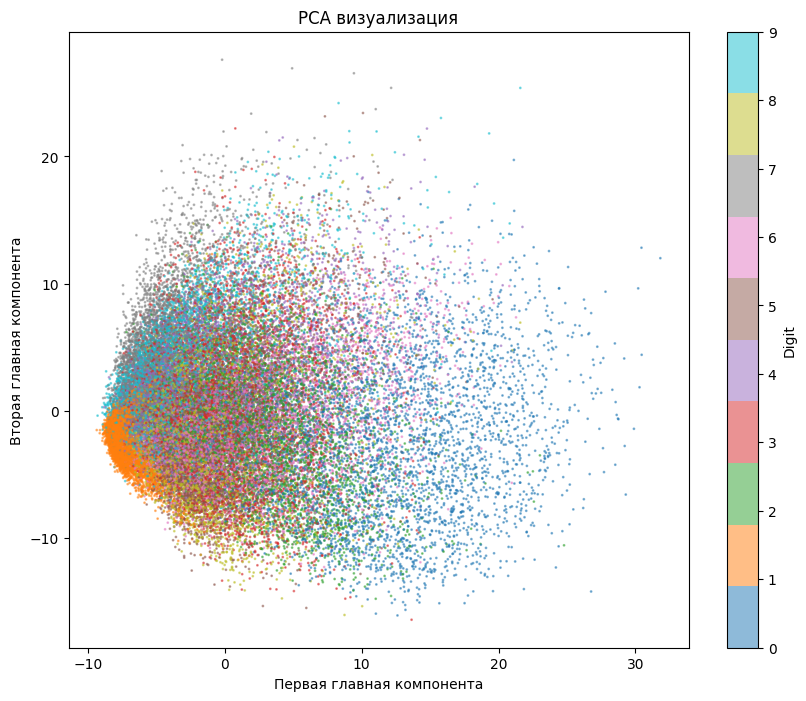

In [12]:
train_features = train[:, 1:]

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)

pca = PCA(n_components=50)
train_pca = pca.fit_transform(train_features_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(train_pca[:, 0], train_pca[:, 1], 
                     c=train_label, cmap='tab10', alpha=0.5, s=1)
plt.colorbar(scatter, label='Digit')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('PCA визуализация')
plt.show()

In [17]:
n_components = train_pca.shape[1]
pca_columns = [f'pca_component_{i}' for i in range(n_components)]
pca_df = pd.DataFrame(train_pca, columns=pca_columns)

combined_df = pd.concat([train_df, pca_df], axis=1)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(combined_df)

X_train, X_val, y_train, y_val = train_test_split(
    train_scaled, train_label, 
    test_size=0.2, 
    random_state=42,
    stratify=train_label
)

randomForest2 = RandomForestClassifier(random_state=12)
randomForest2.fit(X_train, y_train)
y_pred = randomForest2.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       827
         1.0       0.99      0.99      0.99       937
         2.0       0.94      0.96      0.95       835
         3.0       0.93      0.93      0.93       870
         4.0       0.96      0.96      0.96       814
         5.0       0.95      0.92      0.93       759
         6.0       0.96      0.98      0.97       827
         7.0       0.96      0.96      0.96       880
         8.0       0.94      0.91      0.92       813
         9.0       0.92      0.93      0.92       838

    accuracy                           0.95      8400
   macro avg       0.95      0.95      0.95      8400
weighted avg       0.95      0.95      0.95      8400



## Эт чего? Это я снова обучение на валидационной выборке сделал?
## Да вроде нет.

## 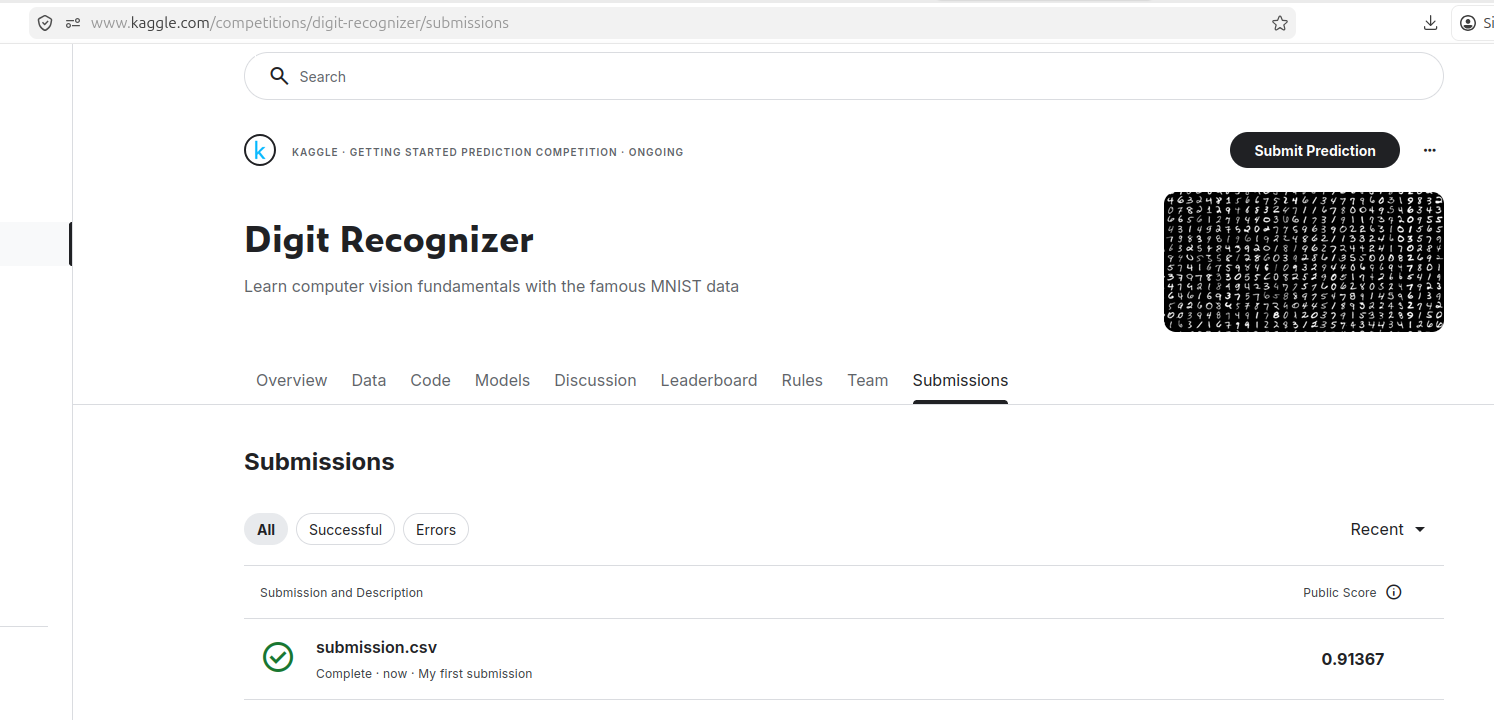

## Mr. Kaggle говорит, что на 91 % решил. Ну явно не накосячил с валидационными данными^^